### Setup

Installs everything this notebook needs — deliberately not `torch` or
`onnx`, only the runtime side. Safe to re-run.


In [1]:
%pip install -q onnxruntime numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


# Inference-only: ONNX Runtime, no PyTorch

This notebook only needs **`onnxruntime`** + **`numpy`** — no `torch` import
anywhere. It loads the `models/mlp.onnx` file produced by `workshop_demo.ipynb`
and runs single-sample and batch inference against it, which is the same
shape a deployed service would use: the training framework is gone, only the
exported graph and a runtime remain.

Run `workshop_demo.ipynb` first if `models/mlp.onnx` doesn't exist yet.


In [2]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort

ONNX_PATH = "models/mlp.onnx"
assert os.path.exists(ONNX_PATH), f"{ONNX_PATH} not found — run workshop_demo.ipynb first"

# only for sanity-checking predictions against the data-generating line;
# not needed to run the model itself
TRUE_M, TRUE_C = 3.5, -1.2


## 1. Load the model and inspect its signature

In [3]:
session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

input_meta = session.get_inputs()[0]
output_meta = session.get_outputs()[0]

print(f"input:  name={input_meta.name!r}  shape={input_meta.shape}  dtype={input_meta.type}")
print(f"output: name={output_meta.name!r}  shape={output_meta.shape}  dtype={output_meta.type}")

input_name = input_meta.name


input:  name='x'  shape=['batch', 1]  dtype=tensor(float)
output: name='y'  shape=['batch', 1]  dtype=tensor(float)


## 2. Single-sample inference

`session.run` takes a list of requested output names (`None` = all of them)
and a dict mapping input name -> numpy array. Every input must be `float32`
and 2-D: `(batch, features)` — even a single sample needs shape `(1, 1)`.


In [4]:
x_single = np.array([[4.0]], dtype=np.float32)
y_single = session.run(None, {input_name: x_single})[0]

print(f"x = {x_single.flatten()[0]}")
print(f"predicted y = {y_single.flatten()[0]:.4f}")
print(f"true line y = {TRUE_M * x_single.flatten()[0] + TRUE_C:.4f}  (no noise)")


x = 4.0
predicted y = 12.7824
true line y = 12.8000  (no noise)


## 3. Batch inference

One call, many rows — no Python-level loop.

In [5]:
batch_size = 8
x_batch = np.linspace(-10, 10, batch_size, dtype=np.float32).reshape(-1, 1)
y_batch = session.run(None, {input_name: x_batch})[0]

for xi, yi in zip(x_batch.flatten(), y_batch.flatten()):
    print(f"x={xi:7.3f}   predicted y={yi:8.3f}   true line={TRUE_M * xi + TRUE_C:8.3f}")


x=-10.000   predicted y= -36.324   true line= -36.200
x= -7.143   predicted y= -26.227   true line= -26.200
x= -4.286   predicted y= -16.131   true line= -16.200
x= -1.429   predicted y=  -6.249   true line=  -6.200
x=  1.429   predicted y=   3.825   true line=   3.800
x=  4.286   predicted y=  13.785   true line=  13.800
x=  7.143   predicted y=  23.813   true line=  23.800
x= 10.000   predicted y=  33.841   true line=  33.800


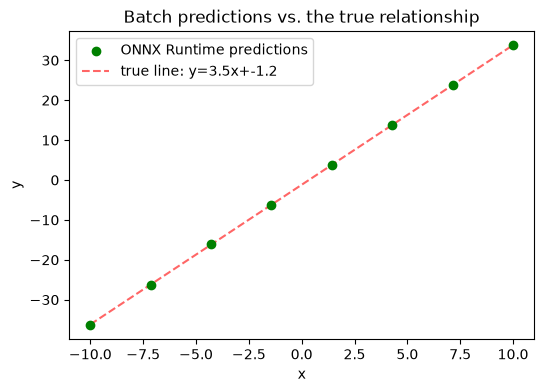

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(x_batch, y_batch, color="green", zorder=3, label="ONNX Runtime predictions")
xs = np.linspace(-10, 10, 100)
plt.plot(xs, TRUE_M * xs + TRUE_C, color="red", linestyle="--", alpha=0.6, label=f"true line: y={TRUE_M}x+{TRUE_C}")
plt.legend()
plt.title("Batch predictions vs. the true relationship")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 4. Arbitrary batch sizes

Because the graph was exported with a dynamic batch axis, the *same* session
accepts any batch size without re-exporting or re-loading anything.


In [7]:
for n in (1, 3, 16, 200):
    x_n = np.random.uniform(-10, 10, size=(n, 1)).astype(np.float32)
    y_n = session.run(None, {input_name: x_n})[0]
    print(f"batch of {n:>4}: input shape {x_n.shape} -> output shape {y_n.shape}")


batch of    1: input shape (1, 1) -> output shape (1, 1)
batch of    3: input shape (3, 1) -> output shape (3, 1)
batch of   16: input shape (16, 1) -> output shape (16, 1)
batch of  200: input shape (200, 1) -> output shape (200, 1)


## 5. Loop-of-singles vs. one batched call

1000 single calls:  2.87 ms
1 batched call:   0.08 ms
speedup: 35.8x


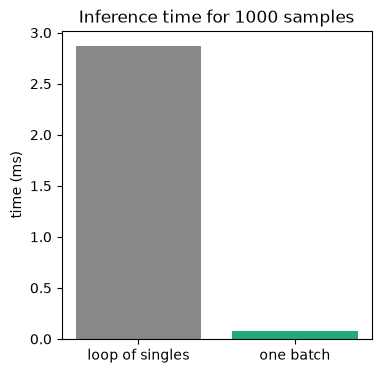

In [8]:
n = 1000
x_many = np.random.uniform(-10, 10, size=(n, 1)).astype(np.float32)

start = time.perf_counter()
for i in range(n):
    session.run(None, {input_name: x_many[i : i + 1]})
loop_time = time.perf_counter() - start

start = time.perf_counter()
session.run(None, {input_name: x_many})
batch_time = time.perf_counter() - start

print(f"{n} single calls:  {loop_time * 1000:.2f} ms")
print(f"1 batched call:   {batch_time * 1000:.2f} ms")
print(f"speedup: {loop_time / batch_time:.1f}x")

plt.figure(figsize=(4, 4))
plt.bar(["loop of singles", "one batch"], [loop_time * 1000, batch_time * 1000], color=["#888", "#2a7"])
plt.ylabel("time (ms)")
plt.title(f"Inference time for {n} samples")
plt.show()


## Takeaways

- Nothing here imports `torch` — the `.onnx` file plus `onnxruntime` is the
  entire runtime dependency for deployment.
- Inputs must match the exported dtype (`float32`) and rank (2-D,
  `batch × features`) — `session.get_inputs()` tells you both up front.
- The dynamic batch axis set at export time means one `InferenceSession`
  serves single requests and large batches alike, with batching giving a
  large speedup from fewer runtime round-trips.
